In [206]:
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 20)


cols = ['survived', 'pclass', 'sex', 'age','sibsp', 'parch', 'fare', 'embarked']
df = sns.load_dataset('titanic')[cols].copy()


print("Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)

Dataset loaded successfully!
Shape (rows, columns): (891, 8)


In [207]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [209]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [210]:
print("Data types:")
print(df.dtypes)
print("\nUnique values per column:")
print(df.nunique())

Data types:
survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

Unique values per column:
survived      2
pclass        3
sex           2
age          88
sibsp         7
parch         7
fare        248
embarked      3
dtype: int64


In [211]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing percentage (%):")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

Missing percentage (%):
survived     0.00
pclass       0.00
sex          0.00
age         19.87
sibsp        0.00
parch        0.00
fare         0.00
embarked     0.22
dtype: float64


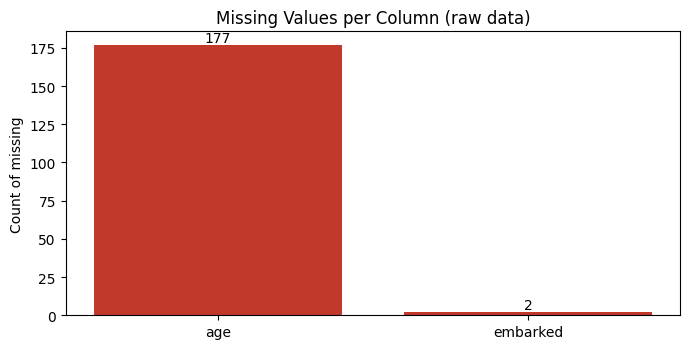

In [212]:
import matplotlib.pyplot as plt

miss = df.isnull().sum()
miss = miss[miss > 0]
plt.figure(figsize=(7, 3.6))
plt.bar(miss.index, miss.values, color='#c0392b')
plt.title('Missing Values per Column (raw data)')
plt.ylabel('Count of missing')
for i, v in enumerate(miss.values):
  plt.text(i, v + 2, str(v), ha='center')
plt.tight_layout()
plt.show()

### Task 1: Instead of the median, fill missing age values with the MEAN. Print the new average age and compare it with the median value (28.0). Which is larger, and why?

In [213]:
df_original = df.copy()
median_age_original = df_original['age'].median()


df['age'] = df['age'].fillna(df['age'].mean())
mean_age_imputed = df['age'].mean()

print(f"Median age (before imputation): {median_age_original}")
print(f"Mean age (after imputation): {mean_age_imputed}")

Median age (before imputation): 28.0
Mean age (after imputation): 29.69911764705882


After imputation:

*   **Median age (before imputation):** 28.0
*   **Mean age (after imputation):** 29.69 (approximately)

In this case, the mean age (29.69) is larger than the median age (28.0). This suggests that the distribution of age in the Titanic dataset is **right-skewed**. A right-skewed distribution means there are a number of higher age values (older passengers) that pull the mean upwards, making it greater than the median.

### Task 2: The pclass column (1, 2, 3) is really a category, not a true number. Apply one-hot encoding to pclass using pd.get_dummies() and show the first 5 rows.

In [214]:
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass', dtype=int)
display(df.head())
print("\nColumns now:", df.columns.tolist())

,survived,sex,age,sibsp,parch,fare,embarked,pclass_1,pclass_2,pclass_3
0,0,male,22.0,1,0,7.2500,S,0,0,1
1,1,female,38.0,1,0,71.2833,C,1,0,0
2,1,female,26.0,0,0,7.9250,S,0,0,1
3,1,female,35.0,1,0,53.1000,S,1,0,0
4,0,male,35.0,0,0,8.0500,S,0,0,1



Columns now: ['survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'pclass_1', 'pclass_2', 'pclass_3']


### Task 3: Apply Min-Max scaling to the sibsp and parch columns. Print the min and max of each scaled column to confirm they lie between 0 and 1.

In [215]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
df[['sibsp_norm', 'parch_norm']] = mm.fit_transform(df[['sibsp', 'parch']])

print(df[['sibsp', 'sibsp_norm', 'parch', 'parch_norm']].head())
print("\nsibsp_norm range:",
round(df['sibsp_norm'].min(), 3), "to", round(df['sibsp_norm'].max(), 3))
print("parch_norm range:",
round(df['parch_norm'].min(), 3), "to", round(df['parch_norm'].max(), 3))

   sibsp  sibsp_norm  parch  parch_norm
0      1       0.125      0         0.0
1      1       0.125      0         0.0
2      0       0.000      0         0.0
3      1       0.125      0         0.0
4      0       0.000      0         0.0

sibsp_norm range: 0.0 to 1.0
parch_norm range: 0.0 to 1.0


### Task 4: Use the IQR method on the age column (instead of fare). How many age outliers are there? Cap them and print the new maximum age.

In [216]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1, " Q3 =", Q3, " IQR =", round(IQR, 4))
print("Lower bound =", round(lower_bound, 4), " Upper bound =", round(upper_bound, 4))

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print("Number of outliers in 'age':", len(outliers))

# Cap the outliers
df['age'] = np.where(df['age'] < lower_bound, lower_bound, df['age'])
df['age'] = np.where(df['age'] > upper_bound, upper_bound, df['age'])

print(f"New maximum age after capping: {df['age'].max():.2f}")

Q1 = 22.0  Q3 = 35.0  IQR = 13.0
Lower bound = 2.5  Upper bound = 54.5
Number of outliers in 'age': 66
New maximum age after capping: 54.50


### Task 5: Change the split to 70% train / 30% test with random_state=1. Print the four new shapes.

In [217]:
from sklearn.model_selection import train_test_split

feature_cols = ['sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'pclass_1', 'pclass_2', 'pclass_3']

X = df[feature_cols]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTraining target balance:")
print(y_train.value_counts(normalize=True).round(3))

X_train shape: (623, 9)
X_test shape: (268, 9)
y_train shape: (623,)
y_test shape: (268,)

Training target balance:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64
